# PICMUS Experiment: Resolution & Distortion

75 plane-wave dataset recorded on a CIRS Multi-Purpose Ultrasound Phantom
(Model 040GSE) with a Verasonics Vantage 256 and L11 probe.
Used in the [PICMUS challenge](http://ieeexplore.ieee.org/document/7728908/).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

## Download and read dataset

In [2]:
DATA_URL = "https://www.ustb.no/datasets/"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "data")
filename = "PICMUS_experiment_resolution_distortion.uff"
filepath = os.path.join(DATA_PATH, filename)

if not os.path.exists(filepath):
    os.makedirs(DATA_PATH, exist_ok=True)
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(DATA_URL + filename, filepath)

from pyuff_ustb.objects.uff import Uff
uff_file = Uff(filepath)
channel_data = uff_file.read("channel_data")
scan = uff_file.read("scan")

print(f"Channel data: {channel_data.N_samples} samples, "
      f"{channel_data.N_channels} channels, "
      f"{channel_data.N_waves} waves")
print(f"Scan: {scan.x.size} pixels")

Channel data: 3328 samples, 128 channels, 75 waves
Scan: 235683 pixels


## Beamform with DAS

Using Tukey 50% window and f-number 1.7 for both transmit and receive
apodization, matching the PICMUS challenge processing parameters.

In [3]:
from ustb.midprocess import DAS
from ustb.enums import Dimension, Window

mid = DAS()
mid.channel_data = channel_data
mid.scan = scan
mid.dimension = Dimension.both
mid.receive_apodization.window = Window.tukey50
mid.receive_apodization.f_number = np.array([1.7, 1.7])
mid.transmit_apodization.window = Window.tukey50
mid.transmit_apodization.f_number = np.array([1.7, 1.7])

b_data = mid.go()

/home/ubuntu/.local/lib/python3.12/site-packages/pyuff_ustb/objects/point.py:60: RuntimeWarning: invalid value encountered in multiply
  return self.distance * np.sin(self.elevation)


/home/ubuntu/.local/lib/python3.12/site-packages/pyuff_ustb/objects/point.py:56: RuntimeWarning: invalid value encountered in multiply
  return self.distance * np.sin(self.azimuth) * np.cos(self.elevation)


USTB Python beamformer...

Completed in 89.23 seconds.


## Display B-mode image

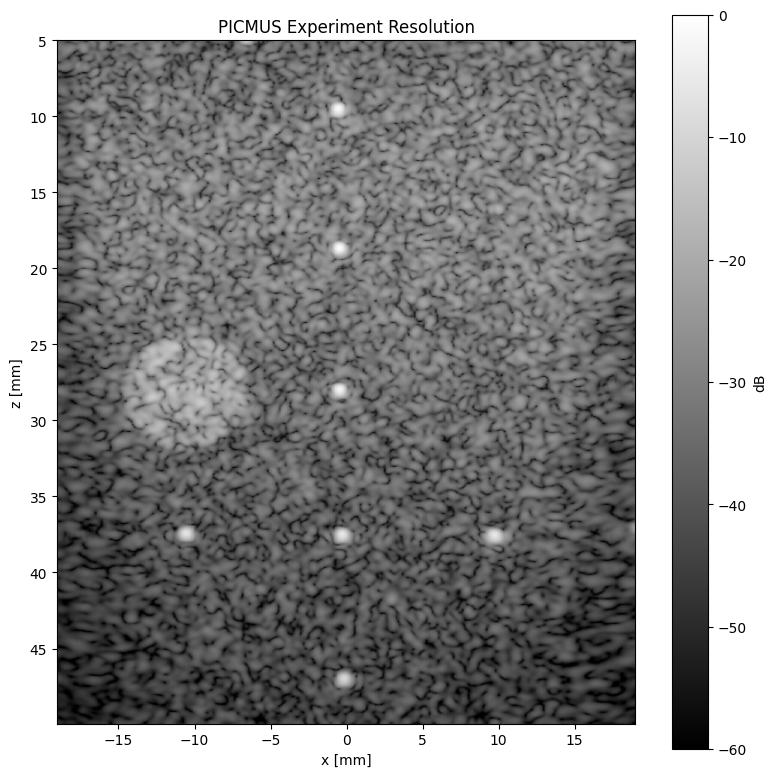

In [4]:
fig, ax = b_data.plot(title="PICMUS Experiment Resolution", dynamic_range=60)
plt.show()